## Classification Exploration 4: Logistic Regression

# [Classification: Logistic Regression](https://en.wikipedia.org/wiki/Logistic_regression)

The IBM HR Analytics Employee Attrition dataset contains fictional data created by IBM data scientists. 
It includes 1,470 employee records with 35 features covering demographics, job roles, satisfaction levels, 
and compensation. The target variable is **Attrition** — whether an employee left the company (Yes/No).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
%matplotlib inline
plt.style.use('ggplot')

df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Drop constant columns
df = df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'StandardHours', 'Over18'])

# Encode categorical columns
df = pd.get_dummies(df, columns=['BusinessTravel', 'Department', 'EducationField',
                                  'Gender', 'JobRole', 'MaritalStatus', 'OverTime'],
                    drop_first=True)

# Encode target variable
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [2]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Attrition'])
y = df['Attrition']

column_names = list(X.columns)

# Fit scaler on full X — we'll use scaled version for visualization later
scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=column_names)

X_scaled.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.108350,...,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,1.591746
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.628241
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.937654,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,1.591746
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.763634,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.591746
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,-0.628241


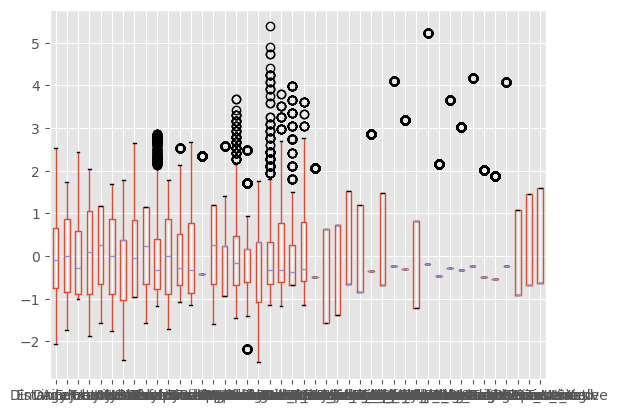

In [3]:
X_scaled.boxplot()
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                     test_size=0.30,
                                                     stratify=y,
                                                     random_state=123)

print(X_train.shape, X_test.shape)

(1029, 44) (441, 44)


## Logistic Regression Model

In [5]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(C=10, solver='lbfgs', max_iter=500)
model.fit(X_train, y_train)

# C: inverse of regularization strength — smaller values = stronger regularization
# solver: algorithm for optimization (lbfgs, newton-cg, liblinear, sag, saga)
# max_iter: maximum iterations for the solver to converge

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [6]:
model.predict(X_test)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [11]:
#DEFINE YOUR CLASSIFIER and THE PARAMETERS GRID
classifier = LogisticRegression()
parameters = {"C": [1e-2, 1e-1, 1], "penalty": ['l2'], "max_iter": [100000]}

In [12]:
#DEFINE YOUR GRIDSEARCH
from sklearn.model_selection import GridSearchCV
gs = GridSearchCV(classifier, parameters, cv=3, scoring='recall', verbose=50, n_jobs=-1, refit=True)

In [13]:
#TRAIN YOUR CLASSIFIER
gs = gs.fit(X_train, y_train)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV 1/3; 1/3] START C=0.01, max_iter=100000, penalty=l2.........................
[CV 2/3; 1/3] START C=0.01, max_iter=100000, penalty=l2.........................
[CV 3/3; 1/3] START C=0.01, max_iter=100000, penalty=l2.........................
[CV 1/3; 2/3] START C=0.1, max_iter=100000, penalty=l2..........................
[CV 2/3; 2/3] START C=0.1, max_iter=100000, penalty=l2..........................
[CV 3/3; 2/3] START C=0.1, max_iter=100000, penalty=l2..........................
[CV 1/3; 3/3] START C=1, max_iter=100000, penalty=l2............................
[CV 2/3; 3/3] START C=1, max_iter=100000, penalty=l2............................
[CV 3/3; 3/3] START C=1, max_iter=100000, penalty=l2............................
[CV 2/3; 1/3] END C=0.01, max_iter=100000, penalty=l2;, score=0.109 total time=   0.7s
[CV 3/3; 1/3] END C=0.01, max_iter=100000, penalty=l2;, score=0.071 total time=   0.8s
[CV 1/3; 1/3] END C=0.01, max_iter=100

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 12888 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 12910 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

[CV 2/3; 2/3] END C=0.1, max_iter=100000, penalty=l2;, score=0.218 total time=   0.9s
[CV 3/3; 2/3] END C=0.1, max_iter=100000, penalty=l2;, score=0.250 total time=   0.9s
[CV 1/3; 3/3] END C=1, max_iter=100000, penalty=l2;, score=0.327 total time=   0.9s


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 12837 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
#summarize the results of your GRIDSEARCH
print('***GRIDSEARCH RESULTS***')
print("Best score: %f using %s" % (gs.best_score_, gs.best_params_))

means = gs.cv_results_['mean_test_score']
stds = gs.cv_results_['std_test_score']
params = gs.cv_results_['params']

for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

***GRIDSEARCH RESULTS***
Best score: 0.331061 using {'C': 1, 'max_iter': 100000, 'penalty': 'l2'}
0.072294 (0.029697) with: {'C': 0.01, 'max_iter': 100000, 'penalty': 'l2'}
0.210606 (0.035662) with: {'C': 0.1, 'max_iter': 100000, 'penalty': 'l2'}
0.331061 (0.034434) with: {'C': 1, 'max_iter': 100000, 'penalty': 'l2'}


In [15]:
#TEST ON YOUR TEST SET
best_model = gs.best_estimator_
y_pred = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

In [16]:
# Print coefficients
print(gs.best_estimator_.coef_)
print(X_train.columns)

[[-2.36776811e-02 -2.87547512e-04  4.02512803e-02  1.23618101e-01
  -3.88674577e-01  2.79673402e-03 -4.43287972e-01 -2.04006615e-01
  -3.88817404e-01 -5.45249526e-05  8.56179385e-06  1.57450743e-01
  -5.49710915e-02  7.62988853e-01 -2.55958580e-01 -2.63970781e-01
  -5.49486991e-02 -1.36075737e-01 -1.84041704e-01  5.51073571e-02
  -1.44116759e-01  1.80903893e-01 -1.09988424e-01  1.18397646e+00
   6.58165799e-01 -1.96427506e-01  4.68467664e-01 -2.31844225e-01
  -6.49469226e-02 -1.71339572e-01 -1.94252570e-01  6.65035788e-01
   3.23162505e-01  2.72454095e-01  6.04729632e-01 -2.93050815e-01
   2.28762725e-01 -2.29122097e-01 -1.66155857e-01  1.70217119e-01
   5.76353789e-01  2.22403277e-01  8.13256045e-01  1.68462436e+00]]
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'Rela

In [17]:
#EVALUATE YOUR PREDICTION
print('***RESULTS ON TRAIN SET***')
print("f1_score: ", metrics.f1_score(y_train, y_pred_train))
print("--")
print('***RESULTS ON TEST SET***')
print("f1_score: ", metrics.f1_score(y_test, y_pred))

***RESULTS ON TRAIN SET***
f1_score:  0.5736434108527132
--
***RESULTS ON TEST SET***
f1_score:  0.6140350877192983


In [18]:
#PRINT SOME FURTHER METRICS
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       370
           1       0.81      0.49      0.61        71

    accuracy                           0.90       441
   macro avg       0.86      0.74      0.78       441
weighted avg       0.89      0.90      0.89       441



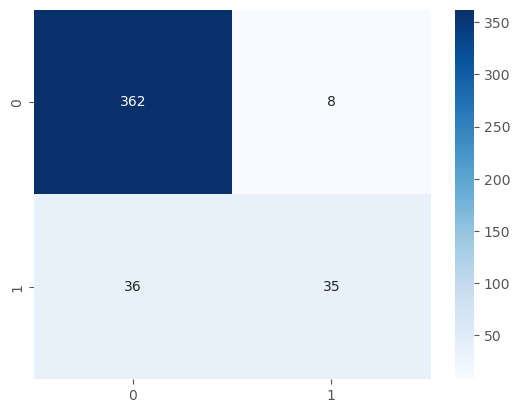

In [19]:
#CONFUSION MATRIX
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues")
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 12837 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


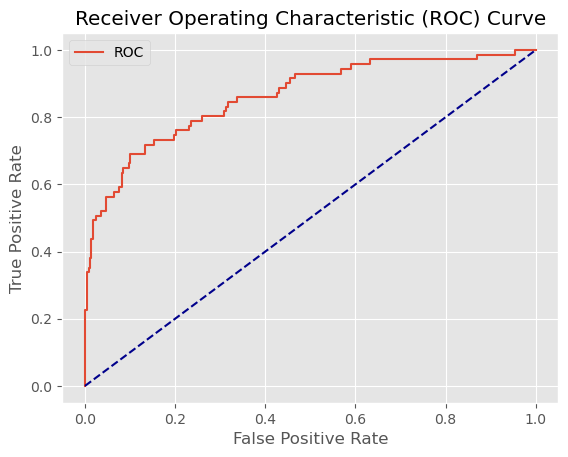

AUC: 0.86


In [20]:
from sklearn import metrics

model = LogisticRegression(C=1, solver='lbfgs', max_iter=100000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

y_probs = model.predict_proba(X_test)

fpr, tpr, thresholds = metrics.roc_curve(y_test, y_probs[:, 1])

plt.plot(fpr, tpr, label='ROC')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

auc = metrics.roc_auc_score(y_test, y_probs[:, 1])
print('AUC: %.2f' % auc)

In [21]:
# Feature coefficients
model.coef_

array([[-2.36776811e-02, -2.87547512e-04,  4.02512803e-02,
         1.23618101e-01, -3.88674577e-01,  2.79673402e-03,
        -4.43287972e-01, -2.04006615e-01, -3.88817404e-01,
        -5.45249526e-05,  8.56179385e-06,  1.57450743e-01,
        -5.49710915e-02,  7.62988853e-01, -2.55958580e-01,
        -2.63970781e-01, -5.49486991e-02, -1.36075737e-01,
        -1.84041704e-01,  5.51073571e-02, -1.44116759e-01,
         1.80903893e-01, -1.09988424e-01,  1.18397646e+00,
         6.58165799e-01, -1.96427506e-01,  4.68467664e-01,
        -2.31844225e-01, -6.49469226e-02, -1.71339572e-01,
        -1.94252570e-01,  6.65035788e-01,  3.23162505e-01,
         2.72454095e-01,  6.04729632e-01, -2.93050815e-01,
         2.28762725e-01, -2.29122097e-01, -1.66155857e-01,
         1.70217119e-01,  5.76353789e-01,  2.22403277e-01,
         8.13256045e-01,  1.68462436e+00]])

In [22]:
# Zip feature names with their coefficients
list(zip(X_train.columns, model.coef_[0, :]))

[('Age', np.float64(-0.023677681055579276)),
 ('DailyRate', np.float64(-0.00028754751179716804)),
 ('DistanceFromHome', np.float64(0.0402512803498253)),
 ('Education', np.float64(0.12361810090420589)),
 ('EnvironmentSatisfaction', np.float64(-0.3886745773166185)),
 ('HourlyRate', np.float64(0.002796734018423102)),
 ('JobInvolvement', np.float64(-0.44328797179366214)),
 ('JobLevel', np.float64(-0.20400661516771992)),
 ('JobSatisfaction', np.float64(-0.3888174035780829)),
 ('MonthlyIncome', np.float64(-5.452495263503987e-05)),
 ('MonthlyRate', np.float64(8.561793847781114e-06)),
 ('NumCompaniesWorked', np.float64(0.1574507433354505)),
 ('PercentSalaryHike', np.float64(-0.05497109149225143)),
 ('PerformanceRating', np.float64(0.7629888526986451)),
 ('RelationshipSatisfaction', np.float64(-0.25595857951081247)),
 ('StockOptionLevel', np.float64(-0.2639707812048936)),
 ('TotalWorkingYears', np.float64(-0.054948699111582046)),
 ('TrainingTimesLastYear', np.float64(-0.13607573712871426)),
 ('

/var/folders/bx/jvqjgdsj5tq7bqvdpl9z20600000gn/T/ipykernel_38469/2038420684.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=X_train.columns, y=model.coef_[0, :], palette="Blues_d")


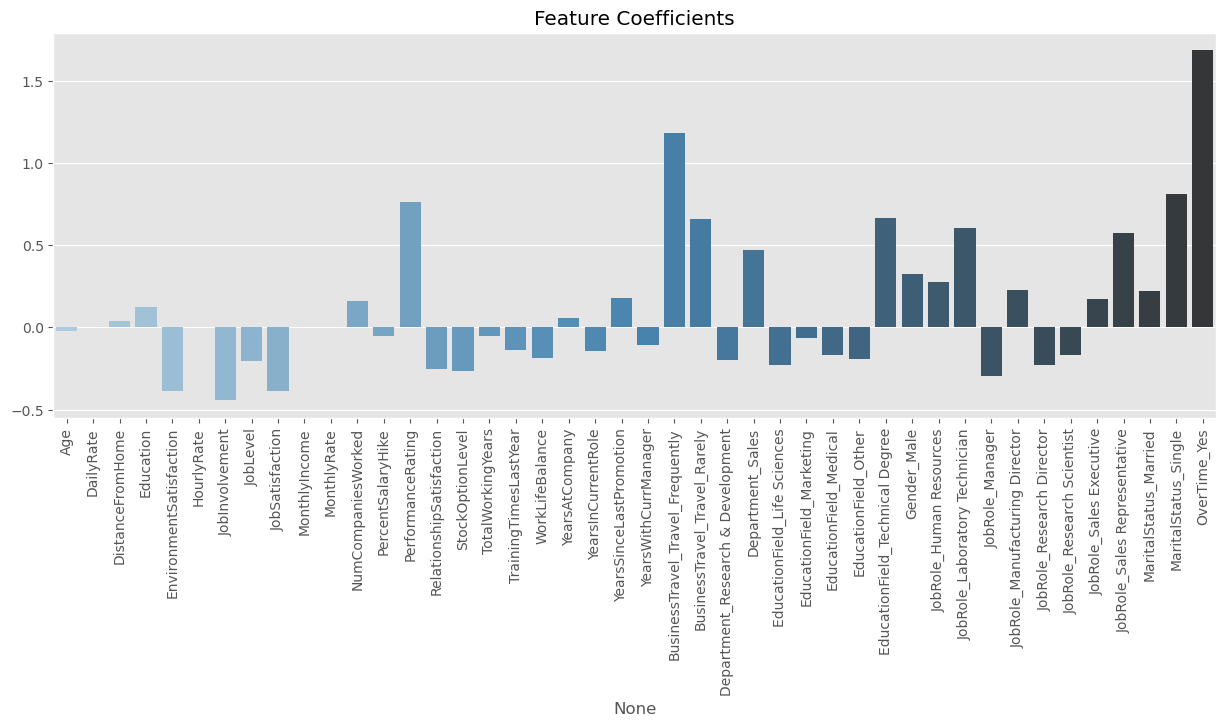

In [23]:
# Plot feature importance via coefficients
plt.figure(figsize=(15, 5))
sns.barplot(x=X_train.columns, y=model.coef_[0, :], palette="Blues_d")
plt.xticks(rotation=90)
plt.title('Feature Coefficients')
plt.show()

In [24]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled_pca = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_pca)

X_pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
X_pca_df["Target"] = y.values
X_pca_df.head()

,PC1,PC2,Target
0,-0.034512,2.271801,1
1,0.097444,-1.569353,0
2,-2.871946,-0.993176,1
3,-1.222608,-1.126880,0
4,-2.075628,-1.211932,0


In [25]:
model_pca = LogisticRegression()
model_pca.fit(X_pca, y)
y_pred_pca = model_pca.predict(X_pca)

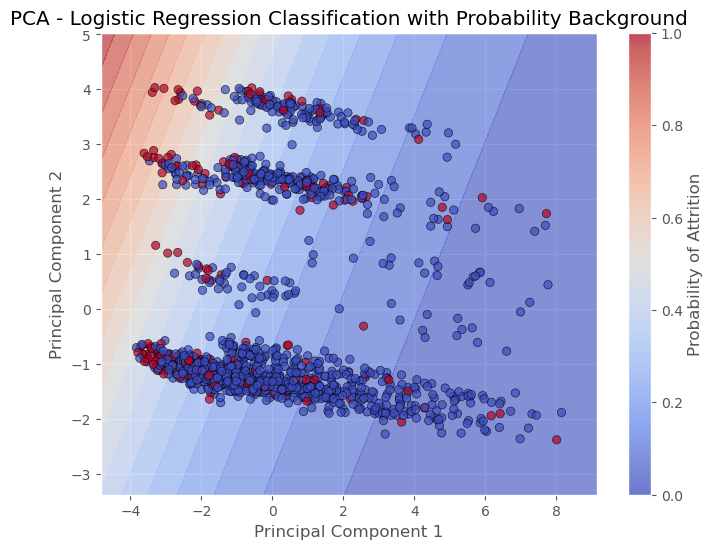

In [26]:
import numpy as np

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

Z = model_pca.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, levels=20, cmap="coolwarm", alpha=0.6)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", edgecolors="k", alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Logistic Regression Classification with Probability Background")
plt.colorbar(label="Probability of Attrition")
plt.show()

## Summary

In this notebook we applied Logistic Regression to predict employee attrition using the IBM HR dataset.

Logistic Regression is the best performing model so far by a significant margin:

- **F1 train = 0.57, F1 test = 0.61** — no overfitting, test actually slightly outperforms train
- **AUC = 0.86** — strong discriminative power

Updated leaderboard:

| Model | F1 Test | AUC |
|-------|---------|-----|
| KNN | 0.22 | 0.54 |
| Decision Tree | 0.44 | 0.69 |
| Naive Bayes | 0.44 | 0.74 |
| Logistic Regression | 0.61 | 0.86 |

Key findings from the feature coefficients:
- **OverTime_Yes** is the strongest predictor of attrition by far
- **BusinessTravel_Frequently** and **MaritalStatus_Single** also strongly increase attrition risk
- **JobLevel** and **JobInvolvement** are protective — higher level and more engaged employees tend to stay
- **EnvironmentSatisfaction** and **JobSatisfaction** reduce attrition risk as expected

The PCA visualization confirms a cleaner linear decision boundary compared to Naive Bayes, consistent with Logistic Regression's linear nature. The class overlap in PCA space explains why F1 is still not perfect despite the strong AUC.

The next notebooks will explore ensemble methods to see if we can push performance even further.